In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [276]:
arsenal = pd.read_excel('Arsenal_DF_22-25.xlsx')
aston_villa = pd.read_excel('AV_Df_22-25.xlsx')
everton = pd.read_excel('Everton_DF_22-25.xlsx')
man_utd = pd.read_excel('Man_Utd_DF_22-25.xlsx')

In [277]:
arsenal

,Player,Date,Venue,Team,Opp,Comp,Result,Start,Min,Pos.,Ht.,Wt.,Age,Season
0,Aaron Ramsdale,2024-03-09,Home,Arsenal,Brentford,Premier League,W 2-1,Y,90,GK,1.95,80,25,2023/24
1,Aaron Ramsdale,2024-01-07,Home,Arsenal,Liverpool,FA Cup,L 0-2,Y,90,GK,1.95,80,25,2023/24
2,Aaron Ramsdale,2023-12-12,Away,Arsenal,PSV Eindhoven,Champions League,D 1-1,Y,90,GK,1.95,80,25,2023/24
3,Aaron Ramsdale,2023-11-25,Away,Arsenal,Brentford,Premier League,W 1-0,Y,90,GK,1.95,80,25,2023/24
4,Aaron Ramsdale,2023-11-01,Away,Arsenal,West Ham,EFL Cup,L 1-3,Y,90,GK,1.95,80,25,2023/24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2389,William Saliba,2022-08-31,Home,Arsenal,Aston Villa,Premier League,W 2-1,Y,90,DF,1.93,76,21,2022/23
2390,William Saliba,2022-08-27,Home,Arsenal,Fulham,Premier League,W 2-1,Y,90,DF,1.93,76,21,2022/23
2391,William Saliba,2022-08-20,Away,Arsenal,Bournemouth,Premier League,W 3-0,Y,90,DF,1.93,76,21,2022/23
2392,William Saliba,2022-08-13,Home,Arsenal,Leicester City,Premier League,W 4-2,Y,90,DF,1.93,76,21,2022/23


In [278]:
everton

,Player,Date,Venue,Team,Opp,Comp,Result,Start,Min,Pos.,Height (m),Weight(kg),Age,Season
0,Abdoulaye Doucoure,2025-05-25,Away,Everton,Newcastle Utd,Premier League,W 1-0,N,15,MF,1.80,60,31,2024/25
1,Abdoulaye Doucoure,2025-05-18,Home,Everton,Southampton,Premier League,W 2-0,Y,64,MF,1.80,60,31,2024/25
2,Abdoulaye Doucoure,2025-05-10,Away,Everton,Fulham,Premier League,W 3-1,Y,60,MF,1.80,60,31,2024/25
3,Abdoulaye Doucoure,2025-04-26,Away,Everton,Chelsea,Premier League,L 0-1,Y,90,MF,1.80,60,31,2024/25
4,Abdoulaye Doucoure,2025-04-19,Home,Everton,Manchester City,Premier League,L 0-2,Y,90,MF,1.80,60,31,2024/25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1616,Youssef Chermiti,2023-10-29,Away,Everton,West Ham,Premier League,W 1-0,N,2,FW,1.91,82,19,2023/24
1617,Youssef Chermiti,2023-10-21,Away,Everton,Liverpool,Premier League,L 0-2,N,3,FW,1.91,82,19,2023/24
1618,Youssef Chermiti,2023-10-07,Home,Everton,Bournemouth,Premier League,W 3-0,N,1,FW,1.91,82,19,2023/24
1619,Youssef Chermiti,2023-09-17,Home,Everton,Arsenal,Premier League,L 0-1,N,3,FW,1.91,82,19,2023/24


In [279]:
aston_villa = aston_villa.iloc[:,[0,1,2,3,4,5,6,7,8,9,11,10,12,13]]

In [280]:
arsenal = arsenal.rename(columns={'Ht.':'Height(m)','Wt.':'Weight(kg)'})

In [281]:
aston_villa = aston_villa.rename(columns={'Ht.':'Height(m)','Wt.':'Weight(kg)'})

In [282]:
man_utd = man_utd.rename(columns={'Ht.':'Height(m)','Wt.':'Weight(kg)'})

In [283]:
everton = everton.rename(columns={'Height (m)':'Height(m)'})

In [2]:
def get_season(date):
    year = date.year
    if date.month >= 8:  # from August, new season starts
        return f"{year}/{str(year+1)[-2:]}"
    else:  # Jan–July belong to the previous season
        return f"{year-1}/{str(year)[-2:]}"

pos_load = {
     "GK":2, "DF":3, "MF":5, "FW":4
}

hi_comp = {"Premier League","Champions League","Europa League"}
def Comp_int(x):
    if x in hi_comp:
        return 5
    elif x == "FA Cup":
        return 4
    elif x == "EFL Cup" or x == "FA Community Shield":
        return 3
    else:
        return 1

def Pos_adjust(x):
    if x == "FW,MF":
        return "FW"
    elif x == "MF,FW":
        return "MF"
    elif x == "MF,DF":
        return "MF"
    elif x == "DF,MF":
        return "DF"
    elif x == "DF,FW":
        return "DF"
    elif x == "FW,DF":
        return "FW"
    else:
        return x

def fixture_5D_count(df):
    
    df = df.copy()
    rolling_counts = []
    for player, grp in df.groupby("Player"):
        grp = grp.set_index("Date").sort_index()
        # Count matches played in the last 5D (non-zero minutes)
        count5 = grp["Min"].gt(0).rolling("5D").sum().values  # .gt(0) = played match
        rolling_counts.extend(count5)
    df["Fixture Count 5D"] = rolling_counts
    return df

def rolling7D(df):
    df = df.copy()
    rolling_vals = []
    for player, grp in df.groupby("Player"):
        grp = grp.set_index("Date").sort_index()
        # this is an array of length grp.shape[0]
        roll7 = grp["Min"].rolling("7D").sum().values
        rolling_vals.extend(roll7)
    df["7D Rolling Avg"] = rolling_vals
    return df
	
def rolling14D(df):
    df = df.copy()
    rolling_vals = []
    for player, grp in df.groupby("Player"):
        grp = grp.set_index("Date").sort_index()
        # this is an array of length grp.shape[0]
        roll7 = grp["Min"].rolling("14D").sum().values
        rolling_vals.extend(roll7)
    df["14D Rolling Avg"] = rolling_vals
    return df

def age_band(age):
    if age <= 21:
        return "developing"
    elif age > 21 and age <=28:
        return "peak"
    elif age > 28 and age <=32:
        return "mature"
    else:
        return "decline"

In [74]:
def df_transform(source):
    df = source.copy()
    match_dates = df["Date"].drop_duplicates().sort_values().tolist()
    players = df["Player"].drop_duplicates().tolist()
    calendar_index = pd.MultiIndex.from_product([players, match_dates], names=["Player", "Date"])
    calendar_df = calendar_index.to_frame(index=False)
    full_df = calendar_df.merge(source,on=["Player","Date"], how="left")
    full_df["Min"] = full_df["Min"].fillna(0)
    for col in ["Pos.","Team"]:
        full_df[col] = full_df.groupby("Player")[col].ffill().bfill()
    full_df = full_df.sort_values(["Player","Date"]).reset_index(drop=True)
    full_df = rolling14D(full_df)
    full_df = rolling7D(full_df)
    full_df = fixture_5D_count(full_df)
    full_df["Primary Position"] = full_df["Pos."].apply(Pos_adjust)
    full_df["Comp Intensity"] = full_df["Comp"].apply(Comp_int)
    full_df["Position Load Score"] = full_df["Pos."].map(pos_load).fillna(3)
    full_df["Season"] = pd.to_datetime(full_df["Date"]).apply(get_season)
    return full_df

In [221]:
def df_transform_v2(source):
    df = source.copy()
    df["Date"] = pd.to_datetime(df["Date"]) #validation
    
    # True active span for each player
    span = df.groupby("Player")["Date"].agg(["min","max"]).reset_index()
    span.rename(columns={"min":"first_game","max":"last_game"}, inplace=True)

    # Collect team-level match dates
    team_dates = df["Date"].drop_duplicates().sort_values()

    # Build per-player calendar only for match dates within their span
    frames = []
    for _, row in span.iterrows():
        player = row["Player"]
        valid_dates = team_dates[(team_dates >= row["first_game"]) & (team_dates <= row["last_game"])]
        cal = pd.DataFrame({"Player": player, "Date": valid_dates})
        frames.append(cal)
    calendar_df = pd.concat(frames, ignore_index=True)

    # Merge with source logs
    full_df = calendar_df.merge(df, on=["Player","Date"], how="left")

    # Fill
    full_df["Min"] = full_df["Min"].fillna(0)
    for col in ["Pos.","Team"]:
        if col in full_df.columns:
            full_df[col] = full_df.groupby("Player")[col].ffill().bfill()
    
    # Sort
    full_df = full_df.sort_values(["Player","Date"]).reset_index(drop=True)

    # Rolling features
    full_df = rolling14D(full_df)
    full_df = rolling7D(full_df)
    full_df = fixture_5D_count(full_df)
    full_df["Fixture Congestion Flag"] = full_df["Fixture Count 5D"] >= 2

    # Position / Comp / Season
    if "Pos." in full_df.columns:
        full_df["Primary Position"] = full_df["Pos."].apply(Pos_adjust)
        full_df["Position Load Score"] = full_df["Pos."].map(pos_load).fillna(3)
    if "Comp" in full_df.columns:
        full_df["Comp Intensity"] = full_df["Comp"].apply(Comp_int)
    full_df["Season"] = full_df["Date"].apply(get_season)

    return full_df


In [314]:
def df_transform_v3(source):
    df = source.copy()
    df["Date"] = pd.to_datetime(df["Date"]) #validation
    
    # True active span for each player
    span = df.groupby("Player")["Date"].agg(["min","max"]).reset_index()
    span.rename(columns={"min":"first_game","max":"last_game"}, inplace=True)

    # Collect team-level match dates
    team_dates = df["Date"].drop_duplicates().sort_values()

    # Build per-player calendar only for match dates within their span
    frames = []
    for row in span.itertuples(index=False):
        player = row.Player
        valid_dates = team_dates[(team_dates >= row.first_game) & (team_dates <= row.last_game)]
        cal = pd.DataFrame({"Player": player, "Date": valid_dates})
        frames.append(cal)
    calendar_df = pd.concat(frames, ignore_index=True)

    # Merge with source logs
    full_df = calendar_df.merge(df, on=["Player","Date"], how="left")

    # Fill
    full_df["Min"] = full_df["Min"].fillna(0)
    for col in ["Pos.","Team","Height(m)", "Weight(kg)", "Age"]:
        if col in full_df.columns:
            full_df[col] = full_df.groupby("Player")[col].ffill().bfill()

    full_df['Age'] = full_df['Age'].astype('int32')
    
    # Sort
    full_df = full_df.sort_values(["Player","Date"]).reset_index(drop=True)

    # Rolling features
    full_df = rolling14D(full_df)
    full_df = rolling7D(full_df)
    full_df = fixture_5D_count(full_df)
    full_df["Fixture Congestion Flag"] = full_df["Fixture Count 5D"] >= 2
    full_df["Age_Group"] = full_df["Age"].apply(age_band)

    # Position / Comp / Season
    if "Pos." in full_df.columns:
        full_df["Primary Position"] = full_df["Pos."].apply(Pos_adjust)
        full_df["Position Load Score"] = full_df["Pos."].map(pos_load).fillna(3)
    if "Comp" in full_df.columns:
        full_df["Comp Intensity"] = full_df["Comp"].apply(Comp_int)
    full_df["Season"] = full_df["Date"].apply(get_season)

    return full_df


In [77]:
arsenal = df_transform(arsenal)

In [103]:
arsenal

,Player,Date,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.
0,Declan Rice,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,90,MF
1,Ben White,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,90,DF
2,Leandro Trossard,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,N,28,FW
3,Gabriel Martinelli,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,69,"FW,MF"
4,Oleksandr Zinchenko,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,69,"DF,MF"
...,...,...,...,...,...,...,...,...,...,...,...
2389,Eddie Nketiah,2022-08-05,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,N,8,FW
2390,Gabriel Jesus,2022-08-05,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,82,FW
2391,Bukayo Saka,2022-08-05,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,90,FW
2392,Granit Xhaka,2022-08-05,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,90,MF


In [79]:
man_utd = df_transform(man_utd)

In [80]:
man_utd

,Player,Date,Venue,Team,Opp,Comp,Result,Start,Min,Pos.,Ht.,Wt.,Age,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Primary Position,Comp Intensity,Position Load Score,Season
0,Aaron Wan-Bissaka,2022-08-07,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,DF,NaN,NaN,NaN,0.0,0.0,0.0,DF,1,3.0,2022/23
1,Aaron Wan-Bissaka,2022-08-13,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,DF,NaN,NaN,NaN,0.0,0.0,0.0,DF,1,3.0,2022/23
2,Aaron Wan-Bissaka,2022-08-22,Home,Manchester Utd,Liverpool,Premier League,W 2-1,N,5.0,DF,1.82,72.0,24.0,5.0,5.0,1.0,DF,5,3.0,2022/23
3,Aaron Wan-Bissaka,2022-08-27,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,DF,NaN,NaN,NaN,5.0,5.0,0.0,DF,1,3.0,2022/23
4,Aaron Wan-Bissaka,2022-09-01,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,DF,NaN,NaN,NaN,5.0,0.0,0.0,DF,1,3.0,2022/23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,Wout Weghorst,2025-05-08,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,FW,NaN,NaN,NaN,0.0,0.0,0.0,FW,1,4.0,2024/25
9392,Wout Weghorst,2025-05-11,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,FW,NaN,NaN,NaN,0.0,0.0,0.0,FW,1,4.0,2024/25
9393,Wout Weghorst,2025-05-16,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,FW,NaN,NaN,NaN,0.0,0.0,0.0,FW,1,4.0,2024/25
9394,Wout Weghorst,2025-05-21,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,FW,NaN,NaN,NaN,0.0,0.0,0.0,FW,1,4.0,2024/25


In [81]:
everton = df_transform(everton)

In [82]:
everton

,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Primary Position,Comp Intensity,Position Load Score,Season
0,Abdoulaye Doucoure,2022-08-06,1608.0,Home,Everton,Chelsea,Premier League,L 0-1,L,Y,90.0,MF,90.0,90.0,1.0,MF,5,5.0,2022/23
1,Abdoulaye Doucoure,2022-08-13,1593.0,Away,Everton,Aston Villa,Premier League,L 1-2,L,Y,34.0,MF,124.0,34.0,1.0,MF,5,5.0,2022/23
2,Abdoulaye Doucoure,2022-08-20,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,34.0,0.0,0.0,MF,1,5.0,2022/23
3,Abdoulaye Doucoure,2022-08-27,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,MF,1,5.0,2022/23
4,Abdoulaye Doucoure,2022-08-30,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,MF,1,5.0,2022/23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5353,Youssef Chermiti,2025-04-26,72.0,Away,Everton,Chelsea,Premier League,L 0-1,L,N,27.0,"FW,MF",27.0,27.0,1.0,FW,5,3.0,2024/25
5354,Youssef Chermiti,2025-05-03,57.0,Home,Everton,Ipswich Town,Premier League,D 2-2,D,N,1.0,"FW,MF",28.0,1.0,1.0,FW,5,3.0,2024/25
5355,Youssef Chermiti,2025-05-10,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,"FW,MF",1.0,0.0,0.0,FW,1,3.0,2024/25
5356,Youssef Chermiti,2025-05-18,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,"FW,MF",0.0,0.0,0.0,FW,1,3.0,2024/25


In [83]:
aston_villa = df_transform(aston_villa)

In [84]:
aston_villa

,Player,Date,Rk,Team,Venue,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Primary Position,Comp Intensity,Position Load Score,Season
0,Aidan Borland,2022-08-06,NaN,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,MF,1,5.0,2022/23
1,Aidan Borland,2022-08-13,NaN,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,MF,1,5.0,2022/23
2,Aidan Borland,2022-08-20,NaN,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,MF,1,5.0,2022/23
3,Aidan Borland,2022-08-23,NaN,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,MF,1,5.0,2022/23
4,Aidan Borland,2022-08-28,NaN,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,MF,1,5.0,2022/23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8619,Ãlex Moreno,2025-04-26,NaN,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,0.0,DF,0.0,0.0,0.0,DF,1,3.0,2024/25
8620,Ãlex Moreno,2025-05-03,NaN,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,0.0,DF,0.0,0.0,0.0,DF,1,3.0,2024/25
8621,Ãlex Moreno,2025-05-10,NaN,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,0.0,DF,0.0,0.0,0.0,DF,1,3.0,2024/25
8622,Ãlex Moreno,2025-05-16,NaN,Aston Villa,NaN,NaN,NaN,NaN,NaN,NaN,0.0,DF,0.0,0.0,0.0,DF,1,3.0,2024/25


In [223]:
%timeit df_transform(aston_villa)

144 ms ± 4.87 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [226]:
df_transform_v2(aston_villa)

,Player,Date,Venue,Team,Opp,Comp,Result,Start,Min,Pos.,...,Weight(kg),Age,Season,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Position Load Score,Comp Intensity
0,Aidan Borland,2024-09-24,Away,Aston Villa,Wycombe,EFL Cup,W 2-1,N,29.0,MF,...,65.0,17.0,2024/25,29.0,29.0,1.0,False,MF,5.0,3
1,Amadou Onana,2024-08-17,Away,Aston Villa,West Ham,Premier League,W 2-1,Y,90.0,MF,...,76.0,22.0,2024/25,90.0,90.0,1.0,False,MF,5.0,5
2,Amadou Onana,2024-08-24,Home,Aston Villa,Arsenal,Premier League,L 0-2,Y,75.0,MF,...,76.0,22.0,2024/25,165.0,75.0,1.0,False,MF,5.0,5
3,Amadou Onana,2024-08-31,Away,Aston Villa,Leicester City,Premier League,W 2-1,Y,60.0,MF,...,76.0,22.0,2024/25,135.0,60.0,1.0,False,MF,5.0,5
4,Amadou Onana,2024-09-14,Home,Aston Villa,Everton,Premier League,W 3-2,Y,45.0,MF,...,76.0,22.0,2024/25,45.0,45.0,1.0,False,MF,5.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3673,Ãlex Moreno,2024-04-18,NaN,Aston Villa,NaN,NaN,NaN,NaN,0.0,DF,...,NaN,NaN,2023/24,29.0,11.0,1.0,False,DF,3.0,1
3674,Ãlex Moreno,2024-04-21,NaN,Aston Villa,NaN,NaN,NaN,NaN,0.0,DF,...,NaN,NaN,2023/24,28.0,0.0,0.0,False,DF,3.0,1
3675,Ãlex Moreno,2024-04-27,NaN,Aston Villa,NaN,NaN,NaN,NaN,0.0,DF,...,NaN,NaN,2023/24,11.0,0.0,0.0,False,DF,3.0,1
3676,Ãlex Moreno,2024-05-02,NaN,Aston Villa,NaN,NaN,NaN,NaN,0.0,DF,...,NaN,NaN,2023/24,0.0,0.0,0.0,False,DF,3.0,1


In [286]:
arsenal = df_transform_v3(arsenal)
aston_villa = df_transform_v3(aston_villa)
everton = df_transform_v3(everton)
man_utd = df_transform_v3(man_utd)

In [287]:
Football_Df = pd.concat([arsenal,aston_villa,everton,man_utd])

In [288]:
Football_Df.to_excel("Football_DF.xlsx", index=False)

In [289]:
Football_Df = Football_Df.reset_index().drop(columns=['index'])

In [290]:
Football_Df.shape

(13991, 21)

In [291]:
Football_Df['Player'].nunique()

197

In [292]:
Football_Df['Team'].nunique()

4

In [293]:
Football_Df['Season'].nunique()

3

In [294]:
Football_Df

,Player,Date,Venue,Team,Opp,Comp,Result,Start,Min,Pos.,...,Weight(kg),Age,Season,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Position Load Score,Comp Intensity
0,Aaron Ramsdale,2022-08-05,Away,Arsenal,Crystal Palace,Premier League,W 2-0,Y,90.0,GK,...,80.0,24,2022/23,90.0,90.0,1.0,False,GK,2.0,5
1,Aaron Ramsdale,2022-08-13,Home,Arsenal,Leicester City,Premier League,W 4-2,Y,90.0,GK,...,80.0,24,2022/23,180.0,90.0,1.0,False,GK,2.0,5
2,Aaron Ramsdale,2022-08-20,Away,Arsenal,Bournemouth,Premier League,W 3-0,Y,90.0,GK,...,80.0,24,2022/23,180.0,90.0,1.0,False,GK,2.0,5
3,Aaron Ramsdale,2022-08-27,Home,Arsenal,Fulham,Premier League,W 2-1,Y,90.0,GK,...,80.0,24,2022/23,180.0,90.0,1.0,False,GK,2.0,5
4,Aaron Ramsdale,2022-08-31,Home,Arsenal,Aston Villa,Premier League,W 2-1,Y,90.0,GK,...,80.0,24,2022/23,270.0,180.0,2.0,True,GK,2.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13986,Wout Weghorst,2023-05-13,Home,Manchester Utd,Wolves,Premier League,W 2-0,N,22.0,"FW,MF",...,84.0,30,2022/23,85.0,78.0,1.0,False,FW,3.0,5
13987,Wout Weghorst,2023-05-20,Away,Manchester Utd,Bournemouth,Premier League,W 1-0,N,34.0,"FW,MF",...,84.0,30,2022/23,112.0,34.0,1.0,False,FW,3.0,5
13988,Wout Weghorst,2023-05-25,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,"FW,MF",...,84.0,30,2022/23,56.0,34.0,0.0,False,FW,3.0,1
13989,Wout Weghorst,2023-05-28,Home,Manchester Utd,Fulham,Premier League,W 2-1,N,14.0,"FW,MF",...,84.0,30,2022/23,48.0,14.0,1.0,False,FW,3.0,5


In [301]:
Football_Df['BMI'] = (Football_Df['Weight(kg)'] / (Football_Df['Height(m)']**2)).round(decimals=3)

In [303]:
Football_Df["BMI_PosLoad"] = Football_Df["BMI"] * Football_Df["Position Load Score"]

In [304]:
numeric_features = [
    "Min", "7D Rolling Avg", "14D Rolling Avg",
    "Fixture Count 5D", "Comp Intensity", "Position Load Score",'Age','BMI','Height(m)','Weight(kg)','BMI_PosLoad'
]

In [305]:
Football_Df[numeric_features]

,Min,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Comp Intensity,Position Load Score,Age,BMI,Height(m),Weight(kg),BMI_PosLoad
0,90.0,90.0,90.0,1.0,5,2.0,24,21.039,1.95,80.0,42.078
1,90.0,90.0,180.0,1.0,5,2.0,24,21.039,1.95,80.0,42.078
2,90.0,90.0,180.0,1.0,5,2.0,24,21.039,1.95,80.0,42.078
3,90.0,90.0,180.0,1.0,5,2.0,24,21.039,1.95,80.0,42.078
4,90.0,180.0,270.0,2.0,5,2.0,24,21.039,1.95,80.0,42.078
...,...,...,...,...,...,...,...,...,...,...,...
13986,22.0,78.0,85.0,1.0,5,3.0,30,21.644,1.97,84.0,64.932
13987,34.0,34.0,112.0,1.0,5,3.0,30,21.644,1.97,84.0,64.932
13988,0.0,34.0,56.0,0.0,1,3.0,30,21.644,1.97,84.0,64.932
13989,14.0,14.0,48.0,1.0,5,3.0,30,21.644,1.97,84.0,64.932


In [306]:
def age_band(age):
    if age <= 21:
        return "developing"
    elif age > 21 and age <=28:
        return "peak"
    elif age > 28 and age <=32:
        return "mature"
    else:
        return "decline"

Football_Df["Age_Group"] = Football_Df["Age"].apply(age_band)


In [307]:
Football_Df["Age_Group"].value_counts()

Age_Group
peak          8097
mature        3011
developing    2295
decline        588
Name: count, dtype: int64

In [308]:
Football_Df["Age_Weight"] = np.exp(-((Football_Df["Age"] - 26)**2) / (2 * 5**2))

In [310]:
Football_Df["Age_Load_Index"] = Football_Df["Age_Weight"] * Football_Df["Position Load Score"]

In [312]:
Football_Df.to_excel("Football_DF.xlsx", index=False)

In [2]:
def _minmax(s):
    """Utility for scaling numeric series to [0,1]"""
    s = s.astype(float).fillna(0.0)
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0


def simulate_injuries(df,
                      injury_rate=0.12,        # target rate ≈ 12% (10–15%)
                      cooldown_days=12,         # min gap between same-player injuries
                      random_state=42):

    rng = np.random.default_rng(random_state)
    out = df.copy()
    out = out.sort_values(["Player", "Date"]).reset_index(drop=True)
    out["Injury"] = 0

    
    p7_hi = np.percentile(out["7D Rolling Avg"], 90)
    p7_med = np.percentile(out["7D Rolling Avg"], 80)
    p14_hi = np.percentile(out["14D Rolling Avg"], 90)
    p14_med = np.percentile(out["14D Rolling Avg"], 75)

    
    out["dnp"] = (out["Min"] == 0)
    out["cameo"] = (out["Min"] <= 15)
    out["no_start"] = (out["Start"] != "Y")

    
    pos_load = {"GK": 2, "DF": 3, "MF": 5, "FW": 4}
    out["PosLoad"] = out["Primary Position"].map(pos_load).fillna(3)

    
    hi_comp = {"Premier League", "Champions League", "Europa League"}
    out["CompHi"] = out["Comp"].isin(hi_comp)

    
    acute = (out["7D Rolling Avg"] >= p7_hi) & (out["dnp"] | out["cameo"])
    chronic = (out["14D Rolling Avg"] >= p14_hi) & (out["dnp"] | out["cameo"])
    conges = (out["Fixture Count 5D"] >= 2) & (out["7D Rolling Avg"] >= p7_med) & (out["no_start"] | out["cameo"])

    out["prev_Min"] = out.groupby("Player")["Min"].shift(1).fillna(0)
    streak = (out["dnp"] & (out["prev_Min"] == 0) & (out["14D Rolling Avg"] >= p14_med))

    context = (
        out["CompHi"] & (out["PosLoad"] >= 4) &
        (out["dnp"] | out["cameo"]) &
        ((out["7D Rolling Avg"] >= p7_med) | (out["14D Rolling Avg"] >= p14_med))
    )

    candidates_mask = acute | chronic | conges | streak | context
    candidates = out[candidates_mask].copy()

    
     # Physiological features
    candidates["Age_Weight"] = np.exp(-((candidates["Age"] - 26)**2) / (2 * 5**2))
    candidates["BMI_Penalty"] = 1 - np.minimum(np.abs(candidates["BMI"] - 22.5) / 10, 1)
    candidates["Age_Load"] = _minmax(candidates["Age"] * candidates["PosLoad"])

        # Combined risk: workload + physiology
    candidates["risk_score"] = (
            0.55 * _minmax(candidates["7D Rolling Avg"]) +
            0.25 * _minmax(candidates["14D Rolling Avg"]) +
            0.10 * candidates["Age_Weight"] +
            0.05 * candidates["BMI_Penalty"] +
            0.05 * candidates["Age_Load"]
    )

    
    TARGET = int(len(out) * injury_rate)
    pool = candidates.sort_values("risk_score", ascending=False)

    # Cooldown logic
    picked_idx = []
    last_injury = {}
    cool = pd.Timedelta(days=cooldown_days)

    for i, row in pool.iterrows():
        p, d = row["Player"], row["Date"]
        if p not in last_injury or (d - last_injury[p]) >= cool:
            picked_idx.append(i)
            last_injury[p] = d
            if len(picked_idx) >= TARGET:
                break

    
    out.loc[picked_idx, "Injury"] = 1

    
    out.drop(columns=["dnp", "cameo", "no_start", "prev_Min", "CompHi","PosLoad"], inplace=True, errors="ignore")

    return out


In [3]:
def boost_injuries(df,
                   target_total = 400,           
                   cooldown_days=10,           
                   min_minutes=55,             
                   thr_7d=150,
                   thr_14d=280,
                   random_state=42):

    rng = np.random.default_rng(random_state)
    out = df.copy()
    out['Injury'] = out['Injury'].fillna(0).astype(int)
    out = out.sort_values(['Player','Date'])

    
    mask = (
        (out['Min'].fillna(0) >= min_minutes) |
        (out['7D Rolling Avg'].fillna(0) >= thr_7d) |
        (out['14D Rolling Avg'].fillna(0) >= thr_14d)
    ) & (out['Injury'] != 1)

    cands = out.loc[mask].copy()

   
    cands["Age_Weight"] = np.exp(-((cands["Age"] - 26)**2) / (2 * 5**2))

   
    cands["BMI_Penalty"] = 1 - np.minimum(np.abs(cands["BMI"] - 22.5) / 10, 1)

   
    cands["Age_Load"] = _minmax(cands["Age"] * cands["PosLoad"])

    
    cands['risk'] = (
        0.55 * _minmax(cands['7D Rolling Avg']) +
        0.25 * _minmax(cands['14D Rolling Avg']) +
        0.10 * cands["Age_Weight"] +
        0.05 * cands["BMI_Penalty"] +
        0.05 * cands["Age_Load"]
    )


    
    cands = cands.sort_values(['risk','Date'], ascending=[False, True])
    picked_idx = []
    last_injury = {}  
    cool = pd.Timedelta(days=cooldown_days)

    
    already = int(out['Injury'].sum())
    need = max(0, int(target_total) - already)
    if need == 0:
        return out

    for i, row in cands.iterrows():
        p, d = row['Player'], row['Date']
        if p not in last_injury or (d - last_injury[p]) >= cool:
            picked_idx.append(i)
            last_injury[p] = d
            if len(picked_idx) >= need:
                break

    out.loc[picked_idx, 'Injury'] = 1
    return out


In [333]:
df = simulate_injuries(Football_Df, injury_rate=0.13, include_physiology=True,cooldown_days=7)

Simulated Injuries: 90 of 13991 (0.64%) | Mode: Workload+Physiology


In [340]:
df = boost_injuries(df, target_total=int(len(df) * 0.13),min_minutes=45,thr_7d=120,thr_14d=250)

In [341]:
df['Injury'].value_counts()

Injury
0    12173
1     1818
Name: count, dtype: int64

In [342]:
df["Injury"].mean() * 100

12.994067614895291

In [343]:
df.to_csv('Injury_simulated_Dataset.csv', index = False)

In [45]:
df = pd.read_csv('Injury_simulated_Dataset.csv')

## Attempting training and splitting on data again

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [46]:
df.columns

Index(['Player', 'Date', 'Venue', 'Team', 'Opp', 'Comp', 'Result', 'Start',
       'Minutes', 'Pos.', 'Height(m)', 'Weight(kg)', 'Age', 'Season',
       'RollingAvg_14d', 'RollingAvg_7d', 'FixtureCount5d',
       'FixtureCongestionFlag', 'PrimaryPosition', 'PositionLoadScore',
       'CompIntensity', 'BMI', 'BMI_PosLoad', 'Age_Group', 'Age_Weight',
       'Age_Load_Index', 'Injury', 'PosLoad'],
      dtype='object')

In [47]:
# Feature groups
numeric_features = ["Min", "RollingAvg_7d","FixtureCount5d", "CompIntensity", "PositionLoadScore","Age","BMI","BMI_PosLoad","Age_Weight"]

binary_features = ["Start", "FixtureCongestionFlag"]

categorical_features = ["Venue", "PrimaryPosition", "Season","Age_Group"]

In [48]:
df['Age_Group'].head()

0    peak
1    peak
2    peak
3    peak
4    peak
Name: Age_Group, dtype: object

In [49]:
drop_columns = ["Player","Team","Opp","Comp","Result","Date","Pos.","Height(m)","Weight(kg)","RollingAvg_14d","Age_Load_Index","PosLoad"]

In [50]:
df.dtypes

Player                    object
Date                      object
Venue                     object
Team                      object
Opp                       object
Comp                      object
Result                    object
Start                      int64
Minutes                  float64
Pos.                      object
Height(m)                float64
Weight(kg)               float64
Age                        int64
Season                    object
RollingAvg_14d           float64
RollingAvg_7d            float64
FixtureCount5d           float64
FixtureCongestionFlag      int64
PrimaryPosition           object
PositionLoadScore        float64
CompIntensity              int64
BMI                      float64
BMI_PosLoad              float64
Age_Group                 object
Age_Weight               float64
Age_Load_Index           float64
Injury                     int64
PosLoad                    int64
dtype: object

In [51]:
df['Venue'] = df['Venue'].fillna("No Match")

In [52]:
df["Venue"].value_counts()

Venue
No Match    4997
Home        4518
Away        4384
Neutral       92
Name: count, dtype: int64

In [53]:
df[categorical_features] = df[categorical_features].astype("category")

In [54]:
df.columns

Index(['Player', 'Date', 'Venue', 'Team', 'Opp', 'Comp', 'Result', 'Start',
       'Minutes', 'Pos.', 'Height(m)', 'Weight(kg)', 'Age', 'Season',
       'RollingAvg_14d', 'RollingAvg_7d', 'FixtureCount5d',
       'FixtureCongestionFlag', 'PrimaryPosition', 'PositionLoadScore',
       'CompIntensity', 'BMI', 'BMI_PosLoad', 'Age_Group', 'Age_Weight',
       'Age_Load_Index', 'Injury', 'PosLoad'],
      dtype='object')

In [42]:
df["Start"] = df["Start"].map({"Y":1,"N":0}).fillna(0).astype('int32')

In [56]:
df["FixtureCongestionFlag"] = df["FixtureCongestionFlag"].fillna(0).astype(int)

In [55]:
df["Start"].value_counts()

Start
0    7380
1    6611
Name: count, dtype: int64

In [64]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, accuracy_score, confusion_matrix, roc_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [58]:
df.columns

Index(['Player', 'Date', 'Venue', 'Team', 'Opp', 'Comp', 'Result', 'Start',
       'Minutes', 'Pos.', 'Height(m)', 'Weight(kg)', 'Age', 'Season',
       'RollingAvg_14d', 'RollingAvg_7d', 'FixtureCount5d',
       'FixtureCongestionFlag', 'PrimaryPosition', 'PositionLoadScore',
       'CompIntensity', 'BMI', 'BMI_PosLoad', 'Age_Group', 'Age_Weight',
       'Age_Load_Index', 'Injury', 'PosLoad'],
      dtype='object')

In [57]:
# X/y
X = df.drop(columns=["Player","Team","Opp","Comp","Result","Date","Pos.","Height(m)","Weight(kg)","RollingAvg_14d","Age_Load_Index","PosLoad"])
y = df["Injury"].astype(int)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)


In [59]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [60]:
# Feature groups
numeric_features = ["Minutes", "RollingAvg_7d","FixtureCount5d", "CompIntensity", "PositionLoadScore","Age","BMI","BMI_PosLoad","Age_Weight"]

binary_features = ["Start", "FixtureCongestionFlag"]

categorical_features = ["Venue", "PrimaryPosition", "Season","Age_Group"]

In [61]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

In [62]:
preprocessor = ColumnTransformer([
    ("num", num_pipe, numeric_features),
    ("bin", bin_pipe, binary_features),
    ("cat", cat_pipe, categorical_features),
])

In [63]:
pipelines = {
    "logreg": Pipeline([("preprocess", preprocessor),
                        ("model", LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=None))]),
    "rf":     Pipeline([("preprocess", preprocessor),
                        ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))]),
    "gb":     Pipeline([("preprocess", preprocessor),
                        ("model", GradientBoostingClassifier(random_state=42))]),
    "hgb":    Pipeline([("preprocess", preprocessor),
                        ("model", HistGradientBoostingClassifier(random_state=42))]),
}


param_grids = {
    "logreg": {
        "model__C": [0.1, 0.5, 1.0, 2.0, 5.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear"]
    },
    "rf": {
        "model__n_estimators": [200, 400, 800],
        "model__max_depth": [None, 10, 20, 40],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "gb": {
        "model__n_estimators": [200, 400, 600],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.7, 0.85, 1.0]
    },
    "hgb": {
        "model__max_depth": [None, 6, 10],
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__max_leaf_nodes": [31, 63, 127],
        "model__l2_regularization": [0.0, 0.1, 1.0]
    },
}

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "accuracy": "accuracy"
}

In [65]:
from time import time as tt
from sklearn.metrics import confusion_matrix

t0 = tt()
results = {}

for name, pipe in pipelines.items():
    grid = param_grids[name]
    
    search = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit="pr_auc",            
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)
    
    # Evaluate on test
    best = search.best_estimator_
    y_prob = best.predict_proba(X_test)[:, 1] if hasattr(best["model"], "predict_proba") else best.decision_function(X_test)
    y_pred = best.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    results[name] = {
    "best_params": search.best_params_,
    "cv_best_scores": search.best_score_,
    "test_roc_auc": roc_auc_score(y_test, y_prob),
    "test_accuracy": accuracy_score(y_test, y_pred),
    "specificity": specificity,
    "sensitivity": sensitivity,
    "report": classification_report(y_test, y_pred, digits=3)
}
print()
print(f'Time taken to train gridsearch: {tt()-t0:.2f} seconds.')
print()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Time taken to train gridsearch: 1719.63 seconds.



In [66]:
for name, res in results.items():
    print(f"\n=== {name.upper()} ===")
    print("Best params:", res["best_params"])
    print(f"CV best: {res['cv_best_scores']:.3f}")
    print(f"Test ROC-AUC: {res['test_roc_auc']:.3f}")
    print(f"Accuracy: {res['test_accuracy']:.3f}")
    print(f"Sensitivity (Recall): {res['sensitivity']:.3f}")
    print(f"Specificity (True Neg Rate): {res['specificity']:.3f}")
    print(res["report"])


=== LOGREG ===
Best params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
CV best: 0.511
Test ROC-AUC: 0.874
Accuracy: 0.757
Sensitivity (Recall): 0.838
Specificity (True Neg Rate): 0.745
              precision    recall  f1-score   support

           0      0.968     0.745     0.842      2435
           1      0.329     0.838     0.473       364

    accuracy                          0.757      2799
   macro avg      0.649     0.791     0.658      2799
weighted avg      0.885     0.757     0.794      2799


=== RF ===
Best params: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 400}
CV best: 0.609
Test ROC-AUC: 0.922
Accuracy: 0.867
Sensitivity (Recall): 0.745
Specificity (True Neg Rate): 0.885
              precision    recall  f1-score   support

           0      0.959     0.885     0.921      2435
           1      0.493     0.745     0.593       364

    accuracy                          0.

In [67]:
gap = res["cv_best_scores"] - res["test_roc_auc"]
print(f"Generalization gap (CV - Test AUC): {gap:.3f}")

Generalization gap (CV - Test AUC): -0.238


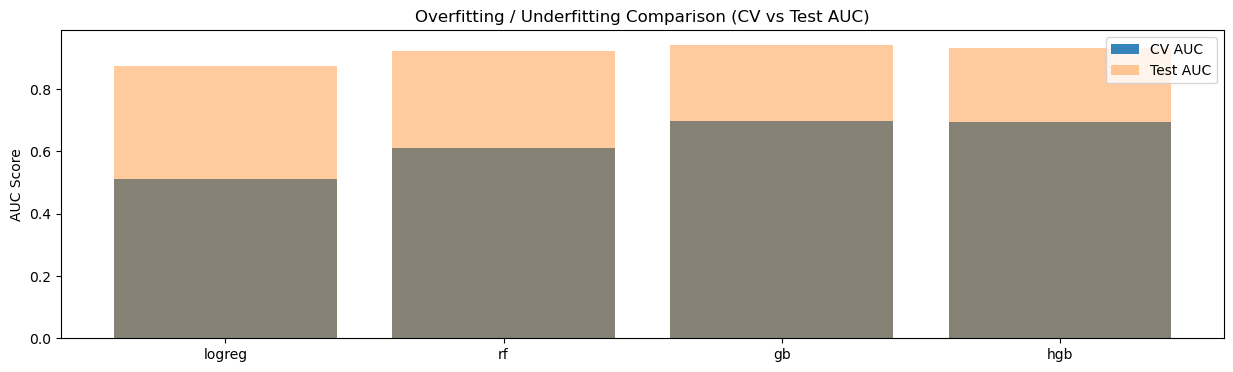

In [68]:
import matplotlib.pyplot as plt

cv_scores = [results[m]['cv_best_scores'] for m in results]
test_scores = [results[m]['test_roc_auc'] for m in results]

plt.figure(figsize=(15,4))
plt.bar(results.keys(), cv_scores, alpha=0.9, label='CV AUC')
plt.bar(results.keys(), test_scores, alpha=0.4, label='Test AUC')
plt.legend()
plt.title("Overfitting / Underfitting Comparison (CV vs Test AUC)")
plt.ylabel("AUC Score")
plt.show()


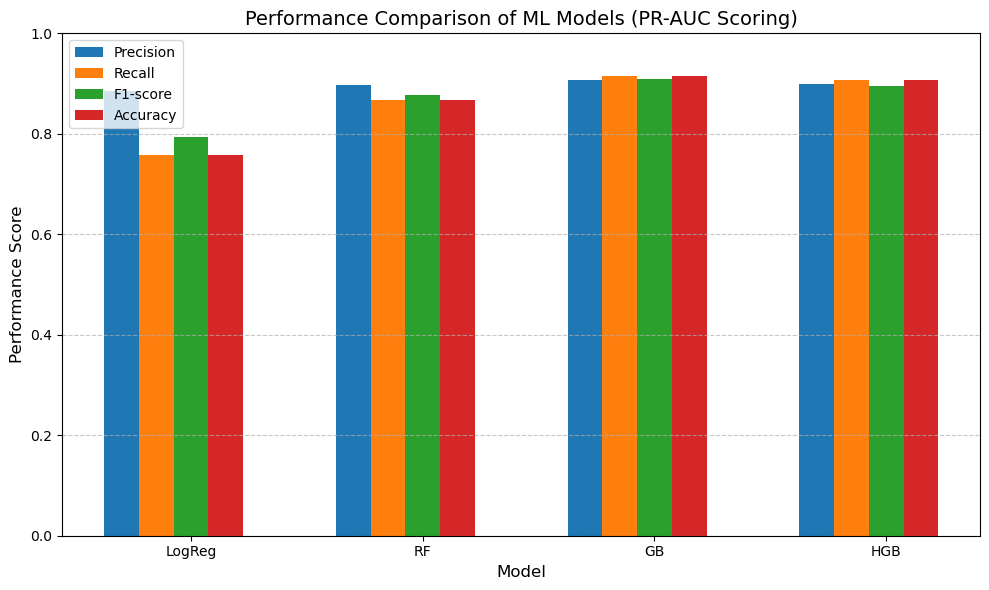

In [33]:
models = ['LogReg', 'RF', 'GB', 'HGB']


precision = [0.885, 0.898, 0.908, 0.899]
recall    = [0.757, 0.867, 0.915, 0.908]
f1        = [0.794, 0.878, 0.909, 0.896]
accuracy  = [0.757, 0.867, 0.915, 0.908]

# Grouped bar chart setup
x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(10,6))
plt.bar(x - 2*width, precision, width, label='Precision')
plt.bar(x - width, recall, width, label='Recall')
plt.bar(x, f1, width, label='F1-score')
plt.bar(x + width, accuracy, width, label='Accuracy')

# Formatting
plt.xlabel('Model', fontsize=12)
plt.ylabel('Performance Score', fontsize=12)
plt.title('Performance Comparison of ML Models (PR-AUC Scoring)', fontsize=14)
plt.xticks(x, models)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [69]:
t0 = tt()
results = {}


for name, pipe in pipelines.items():
    grid = param_grids[name]
    
    search = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit="roc_auc",            
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)
    
    # Evaluate on test
    best = search.best_estimator_
    y_prob = best.predict_proba(X_test)[:, 1] if hasattr(best["model"], "predict_proba") else best.decision_function(X_test)
    y_pred = best.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    results[name] = {
    "best_params": search.best_params_,
    "cv_best_scores": search.best_score_,
    "test_roc_auc": roc_auc_score(y_test, y_prob),
    "test_accuracy": accuracy_score(y_test, y_pred),
    "specificity": specificity,
    "sensitivity": sensitivity,
    "report": classification_report(y_test, y_pred, digits=3)
}
print()
print(f'Time taken to train gridsearch: {tt()-t0:.2f} seconds.')
print()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Time taken to train gridsearch: 1472.75 seconds.



In [70]:
for name, res in results.items():
    print(f"\n=== {name.upper()} ===")
    print("Best params:", res["best_params"])
    print(f"CV best: {res['cv_best_scores']:.3f}")
    print(f"Test ROC-AUC: {res['test_roc_auc']:.3f}")
    print(f"Accuracy: {res['test_accuracy']:.3f}")
    print(f"Sensitivity (Recall): {res['sensitivity']:.3f}")
    print(f"Specificity (True Neg Rate): {res['specificity']:.3f}")
    print(res["report"])


=== LOGREG ===
Best params: {'model__C': 2.0, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
CV best: 0.867
Test ROC-AUC: 0.874
Accuracy: 0.756
Sensitivity (Recall): 0.843
Specificity (True Neg Rate): 0.743
              precision    recall  f1-score   support

           0      0.969     0.743     0.841      2435
           1      0.329     0.843     0.474       364

    accuracy                          0.756      2799
   macro avg      0.649     0.793     0.658      2799
weighted avg      0.886     0.756     0.794      2799


=== RF ===
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 800}
CV best: 0.917
Test ROC-AUC: 0.924
Accuracy: 0.874
Sensitivity (Recall): 0.728
Specificity (True Neg Rate): 0.896
              precision    recall  f1-score   support

           0      0.957     0.896     0.925      2435
           1      0.512     0.728     0.601       364

    accuracy                          

In [71]:
gap = res["cv_best_scores"] - res["test_roc_auc"]
print(f"Generalization gap (CV - Test AUC): {gap:.3f}")

Generalization gap (CV - Test AUC): 0.002


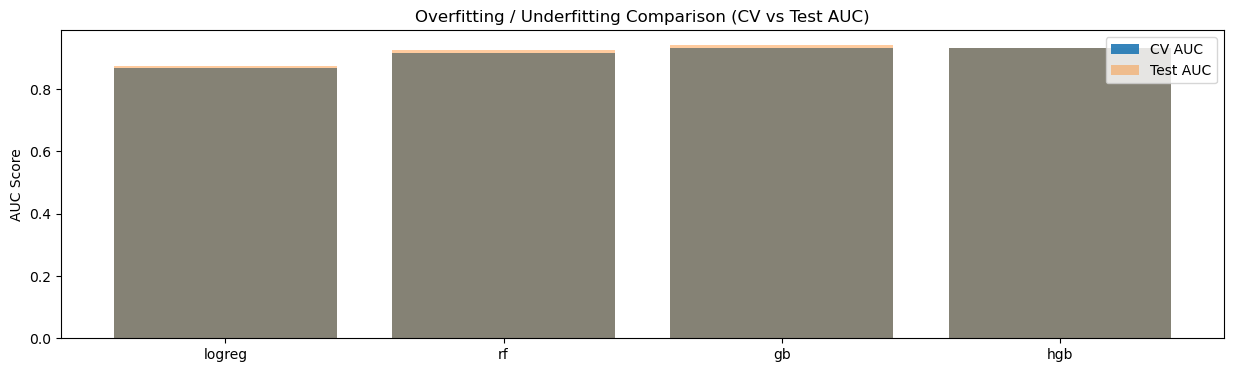

In [72]:
cv_scores = [results[m]['cv_best_scores'] for m in results]
test_scores = [results[m]['test_roc_auc'] for m in results]

plt.figure(figsize=(15,4))
plt.bar(results.keys(), cv_scores, alpha=0.9, label='CV AUC')
plt.bar(results.keys(), test_scores, alpha=0.4, label='Test AUC')
plt.legend()
plt.title("Overfitting / Underfitting Comparison (CV vs Test AUC)")
plt.ylabel("AUC Score")
plt.show()


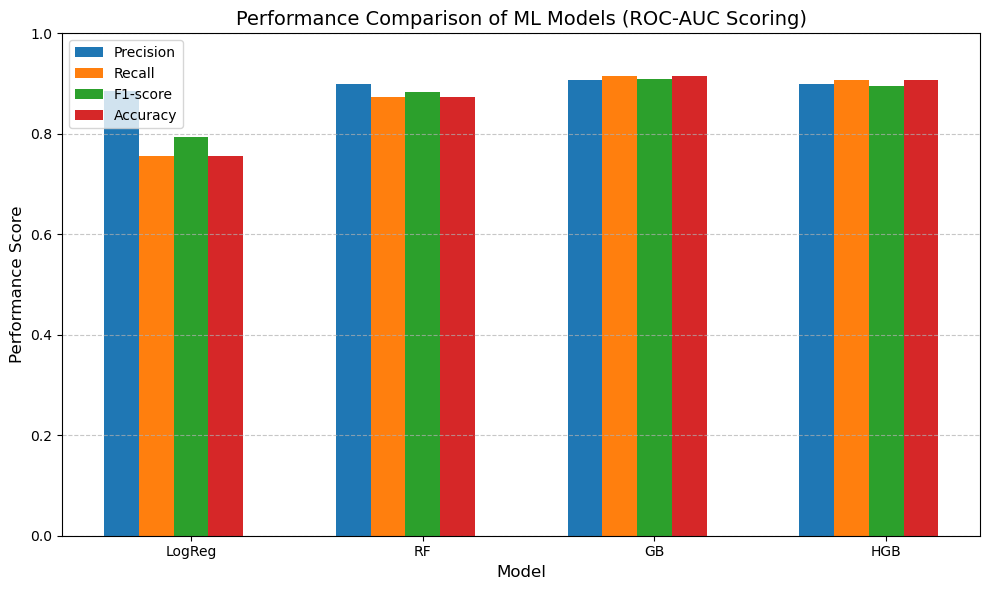

In [73]:
models = ['LogReg', 'RF', 'GB', 'HGB']


precision = [0.886, 0.899, 0.908, 0.899]
recall    = [0.756, 0.874, 0.915, 0.908]
f1        = [0.794, 0.883, 0.909, 0.896]
accuracy  = [0.756, 0.874, 0.915, 0.908]

# Grouped bar chart setup
x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(10,6))
plt.bar(x - 2*width, precision, width, label='Precision')
plt.bar(x - width, recall, width, label='Recall')
plt.bar(x, f1, width, label='F1-score')
plt.bar(x + width, accuracy, width, label='Accuracy')

# Formatting
plt.xlabel('Model', fontsize=12)
plt.ylabel('Performance Score', fontsize=12)
plt.title('Performance Comparison of ML Models (ROC-AUC Scoring)', fontsize=14)
plt.xticks(x, models)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [459]:
X_train_transformed = best.named_steps["preprocess"].transform(X_train)

def clean_column(name):
    return name.replace("/", "_").replace(" ", "_").replace("-", "_")

feature_names = [clean_column(f) for f in (
    numeric_features +
    binary_features +
    list(best.named_steps["preprocess"]
         .named_transformers_["cat"]
         .get_feature_names_out(categorical_features))
)]


X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_train_df["Injury"] = y_train.values

import statsmodels.formula.api as smf
formula = "Injury ~ " + " + ".join(feature_names)
logit_model = smf.logit(formula, data=X_train_df).fit()
print(logit_model.summary())


SyntaxError: invalid syntax (<unknown>, line 1)

In [460]:
feature_names

['Min',
 '7D_Rolling_Avg',
 'Fixture_Count_5D',
 'Comp_Intensity',
 'Position_Load_Score',
 'Age',
 'BMI',
 'BMI_PosLoad',
 'Age_Weight',
 'Start',
 'Fixture_Congestion_Flag',
 'Venue_Away',
 'Venue_Home',
 'Venue_Neutral',
 'Venue_No_Match',
 'Primary_Position_DF',
 'Primary_Position_FW',
 'Primary_Position_GK',
 'Primary_Position_MF',
 'Season_2022_23',
 'Season_2023_24',
 'Season_2024_25',
 'Age_Group_decline',
 'Age_Group_developing',
 'Age_Group_mature',
 'Age_Group_peak']

In [461]:
import re
import pandas as pd
import statsmodels.formula.api as smf

# 1) Transform X_train with your fitted preprocessor
X_train_transformed = best.named_steps["preprocess"].transform(X_train)

# 2) Build the raw feature name list from your pipeline
raw_feature_names = (
    numeric_features
    + binary_features
    + list(
        best.named_steps["preprocess"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

# 3) Make names formula-safe
def make_safe(name: str) -> str:
    s = re.sub(r"\W+", "_", str(name)).strip("_")   # keep letters/digits/underscore
    if re.match(r"^\d", s):                         # if starts with a digit, prefix
        s = "F_" + s
    return s

# handle duplicates after cleaning
def safe_dedup(names):
    seen = {}
    out = []
    for n in names:
        if n not in seen:
            seen[n] = 1
            out.append(n)
        else:
            seen[n] += 1
            out.append(f"{n}_{seen[n]}")
    return out

safe_feature_names = [make_safe(n) for n in raw_feature_names]
safe_feature_names = safe_dedup(safe_feature_names)

# 4) Build DataFrame for statsmodels with safe names
Xsm = pd.DataFrame(X_train_transformed, columns=safe_feature_names)
Xsm["Injury"] = y_train.values  # binary target 0/1

# 5) Fit statsmodels Logit with a formula string
formula = "Injury ~ " + " + ".join(safe_feature_names)  # constant is added by formula API
logit_model = smf.logit(formula, data=Xsm).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.267904
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 Injury   No. Observations:                11192
Model:                          Logit   Df Residuals:                    11169
Method:                           MLE   Df Model:                           22
Date:                Fri, 10 Oct 2025   Pseudo R-squ.:                  0.3064
Time:                        11:12:40   Log-Likelihood:                -2998.4
converged:                       True   LL-Null:                       -4322.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -1.3148        nan        nan        nan         nan  

In [437]:
best.named_steps

{'preprocess': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['Min', '7D Rolling Avg', 'Fixture Count 5D',
                                   'Comp Intensity', 'Position Load Score',
                                   'Age', 'BMI', 'BMI_PosLoad', 'Age_Weight']),
                                 ('bin',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent'))]),
                                  ['Start', 'Fixture Congestion Flag']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
            

In [462]:
best_model_name = "rf"
best_estimator = search.best_estimator_  # after your GridSearchCV loop

# Predict probabilities and labels on test data
y_pred = best_estimator.predict(X_test)
y_prob = best_estimator.predict_proba(X_test)[:, 1]

# Evaluate
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

# Optional: feature importance
importances = best_estimator.named_steps["model"].feature_importances_
feat_names = (
    numeric_features
    + binary_features
    + list(best_estimator.named_steps["preprocess"]
           .named_transformers_["cat"]
           .get_feature_names_out(categorical_features))
)
fi_df = pd.DataFrame({"Feature": feat_names, "Importance": importances})
fi_df.sort_values("Importance", ascending=False).head(15)


ROC-AUC: 0.9307895390030912
Classification Report:
              precision    recall  f1-score   support

           0      0.918     0.982     0.949      2435
           1      0.774     0.415     0.540       364

    accuracy                          0.908      2799
   macro avg      0.846     0.698     0.745      2799
weighted avg      0.899     0.908     0.896      2799



AttributeError: 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'

In [463]:
best_estimator.named_steps

{'preprocess': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['Min', '7D Rolling Avg', 'Fixture Count 5D',
                                   'Comp Intensity', 'Position Load Score',
                                   'Age', 'BMI', 'BMI_PosLoad', 'Age_Weight']),
                                 ('bin',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent'))]),
                                  ['Start', 'Fixture Congestion Flag']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
            

## Model testing on external data

In [74]:
import pandas as pd
import numpy as np
import matplotlib as plt


df = pd.read_csv('Injury_simulated_Dataset.csv', parse_dates=['Date'], date_format="%Y-%m-%d")

rename_map = {
    "7D Rolling Avg": "RollingAvg_7d",
    "14D Rolling Avg": "RollingAvg_14d",
    "Fixture Count 5D": "FixtureCount5d",
    "Fixture Congestion Flag": "FixtureCongestionFlag",
    "Comp Intensity": "CompIntensity",
    "Position Load Score": "PositionLoadScore",
    "Age Load Index": "Age_Load_Index",
    "Age Weight": "Age_Weight",
    "Primary Position": "PrimaryPosition",
    "Age Group": "Age_Group",
    "Min": "Minutes"
}

df.rename(columns=rename_map, inplace=True)

# Feature groups
numeric_features = ["Minutes", "RollingAvg_7d", "FixtureCount5d", "CompIntensity", "PositionLoadScore", "Age", "BMI",
                    "BMI_PosLoad", "Age_Weight"]

binary_features = ["Start", "FixtureCongestionFlag"]

categorical_features = ["Venue", "PrimaryPosition", "Season", "Age_Group"]


df['Venue'] = df['Venue'].fillna("No Match")
df["Venue"].value_counts()
df[categorical_features] = df[categorical_features].astype("category")
df["Start"] = df["Start"].map({"Y": 1, "N": 0}).fillna(0).astype('int32')
df["FixtureCongestionFlag"] = df["FixtureCongestionFlag"].fillna(0).astype(int)
df["Start"].value_counts()
# ---------------------------
# 0) Prepare data
# ---------------------------

# X/y
X = df.drop(
    columns=["Player", "Team", "Opp", "Comp", "Result", "Date", "Pos.", "Height(m)", "Weight(kg)", "RollingAvg_14d",
             "Age_Load_Index", "PosLoad"])
y = df["Injury"].astype(int)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)


In [40]:
df.to_csv('Injury_simulated_Dataset.csv', index=False)

In [76]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, accuracy_score, confusion_matrix

import re
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib as plt

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import statsmodels.api as sm
import statsmodels.formula.api as smf



num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, numeric_features),
    ("bin", bin_pipe, binary_features),
    ("cat", cat_pipe, categorical_features),
])

In [ ]:
pipelines = {
    "logreg": Pipeline([("preprocess", preprocessor),
                        ("model", LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=None))]),
    "rf":     Pipeline([("preprocess", preprocessor),
                        ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))]),
    "gb":     Pipeline([("preprocess", preprocessor),
                        ("model", GradientBoostingClassifier(random_state=42))]),
    "hgb":    Pipeline([("preprocess", preprocessor),
                        ("model", HistGradientBoostingClassifier(random_state=42))]),
}

In [91]:
t0 = tt()

# Rebuild final Random Forest pipeline
final_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_estimators=800,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=1
    ))
])

# Fit on the full training set
final_rf.fit(X_train, y_train)

# Evaluate
y_pred = final_rf.predict(X_test)
y_prob = final_rf.predict_proba(X_test)[:, 1]

print("Final Random Forest Results:")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=3))

print(f'Time taken: {tt()-t0:.2f} seconds.')

Final Random Forest Results:
ROC-AUC: 0.9236940677392423
PR-AUC: 0.6051699772037454
              precision    recall  f1-score   support

           0      0.955     0.897     0.925      2435
           1      0.510     0.720     0.597       364

    accuracy                          0.874      2799
   macro avg      0.733     0.808     0.761      2799
weighted avg      0.897     0.874     0.882      2799

Time taken: 5.87 seconds.


In [80]:
t0 = tt()

# Rebuild final Log reg pipeline
final_lg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(C=1.0, solver='liblinear',max_iter=1000        
    ))
])

# Fit on the full training set
final_lg.fit(X_train, y_train)

# Evaluate
y_pred = final_lg.predict(X_test)
y_prob = final_lg.predict_proba(X_test)[:, 1]

print("Final Log Reg Results:")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=3))

print(f'Time taken: {tt()-t0:.2f} seconds.')

Final Log Reg Results:
ROC-AUC: 0.8728219419184511
              precision    recall  f1-score   support

           0      0.902     0.974     0.937      2435
           1      0.627     0.291     0.398       364

    accuracy                          0.885      2799
   macro avg      0.765     0.633     0.667      2799
weighted avg      0.866     0.885     0.867      2799

Time taken: 0.11 seconds.


In [81]:
t0 = tt()

# Rebuild final Random Forest pipeline
final_gb = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(learning_rate=0.05, n_estimators=400, max_depth=5
    ))
])

# Fit on the full training set
final_gb.fit(X_train, y_train)

# Evaluate
y_pred = final_gb.predict(X_test)
y_prob = final_gb.predict_proba(X_test)[:, 1]

print("Final Gradient Boosting Results:")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=3))

print(f'Time taken: {tt()-t0:.2f} seconds.')

Final Gradient Boosting Results:
ROC-AUC: 0.9365706162420742
              precision    recall  f1-score   support

           0      0.920     0.975     0.947      2435
           1      0.724     0.431     0.540       364

    accuracy                          0.905      2799
   macro avg      0.822     0.703     0.744      2799
weighted avg      0.894     0.905     0.894      2799

Time taken: 8.00 seconds.


In [82]:
t0 = tt()

# Rebuild final Random Forest pipeline
final_hgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingClassifier(learning_rate=0.05, max_depth=20, l2_regularization=0.1
    ))
])

# Fit on the full training set
final_hgb.fit(X_train, y_train)

# Evaluate
y_pred = final_hgb.predict(X_test)
y_prob = final_hgb.predict_proba(X_test)[:, 1]

print("Final HistGradient Boosting Results:")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=3))

print(f'Time taken: {tt()-t0:.2f} seconds.')

Final HistGradient Boosting Results:
ROC-AUC: 0.9320554189137351
              precision    recall  f1-score   support

           0      0.914     0.983     0.947      2435
           1      0.769     0.385     0.513       364

    accuracy                          0.905      2799
   macro avg      0.842     0.684     0.730      2799
weighted avg      0.896     0.905     0.891      2799

Time taken: 0.42 seconds.


In [84]:
import joblib
joblib.dump(final_lg, "final_lg_model.pkl")
joblib.dump(final_gb, "final_gb_model.pkl")
joblib.dump(final_hgb, "final_hgb_model.pkl")

['final_hgb_model.pkl']

### Testing for ROC score on Validation data (liverpool fc)

In [87]:
models = {
    "Logistic Regression": joblib.load("final_lg_model.pkl"),
    "Random Forest": joblib.load("final_rf_model.pkl"),
    "Gradient Boosting": joblib.load("final_gb_model.pkl"),
    "HistGradient Boosting": joblib.load("final_hgb_model.pkl")
}

C:\Users\Ganesh\anaconda3\envs\Project_MSC\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Ganesh\anaconda3\envs\Project_MSC\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Ganesh\anaconda3\envs\Project_MSC\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.2 when u

In [90]:
from df_functions_4 import df_transform_v4


liverpool_df = pd.read_csv("liverpool.csv")
liverpool_transformed = df_transform_v4(liverpool_df)
X_liv = liverpool_transformed.drop(columns=["Injury"])
y_liv = liverpool_transformed["Injury"]

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xef in position 183840: invalid continuation byte

In [ ]:
external_results = {}

for name, model in models.items():
    y_prob = model.predict_proba(X_liv)[:, 1]
    y_pred = model.predict(X_liv)
    roc_auc = roc_auc_score(y_liv, y_prob)
    pr_auc = average_precision_score(y_liv, y_prob)
    report = classification_report(y_liv, y_pred, digits=3)
    external_results[name] = {
        "ROC–AUC": roc_auc,
        "PR–AUC": pr_auc,
        "Classification Report": report
    }

for k, v in external_results.items():
    print(f"\n{k}\nROC–AUC: {v['ROC–AUC']:.3f} | PR–AUC: {v['PR–AUC']:.3f}\n{v['Classification Report']}")


In [42]:
import re
import pandas as pd
import statsmodels.formula.api as smf

X_train_transformed = final_rf.named_steps["preprocess"].transform(X_train)

raw_feature_names = (
    numeric_features
    + binary_features
    + list(
        final_rf.named_steps["preprocess"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

def make_safe(name: str) -> str:
    s = re.sub(r"\W+", "_", str(name)).strip("_")   # keep letters/digits/underscore
    if re.match(r"^\d", s):                         # if starts with a digit, prefix
        s = "F_" + s
    return s

# handle duplicates after cleaning
def safe_dedup(names):
    seen = {}
    out = []
    for n in names:
        if n not in seen:
            seen[n] = 1
            out.append(n)
        else:
            seen[n] += 1
            out.append(f"{n}_{seen[n]}")
    return out

safe_feature_names = [make_safe(n) for n in raw_feature_names]
safe_feature_names = safe_dedup(safe_feature_names)

# 4) Build DataFrame for statsmodels with safe names
Xsm = pd.DataFrame(X_train_transformed, columns=safe_feature_names)
Xsm["Injury"] = y_train.values  # binary target 0/1

# 5) Fit statsmodels Logit with a formula string
formula = "Injury ~ " + " + ".join(safe_feature_names)  # constant is added by formula API
logit_model = smf.logit(formula, data=Xsm).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.267904
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 Injury   No. Observations:                11192
Model:                          Logit   Df Residuals:                    11169
Method:                           MLE   Df Model:                           22
Date:                Mon, 27 Oct 2025   Pseudo R-squ.:                  0.3064
Time:                        16:52:02   Log-Likelihood:                -2998.4
converged:                       True   LL-Null:                       -4322.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.3148        nan        nan        nan         nan        

In [477]:
# Optional: save for later
import joblib
joblib.dump(final_rf, "final_rf_model.pkl")


['final_rf_model.pkl']


Confusion Matrix:
[[2182  253]
 [  99  265]]


<Figure size 600x600 with 0 Axes>

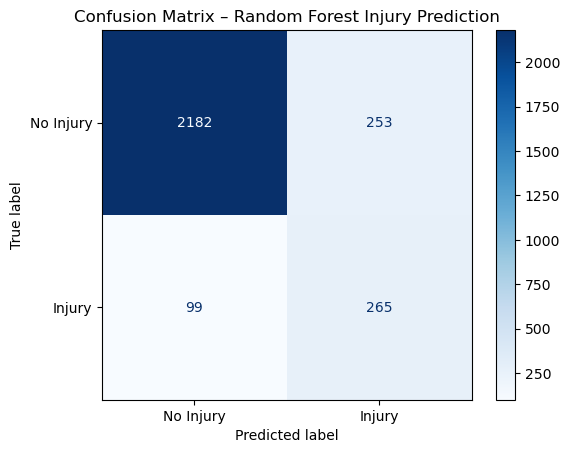

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Injury", "Injury"])

print("\nConfusion Matrix:")
print(cm)

# --- Plot Confusion Matrix ---
plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix – Random Forest Injury Prediction")
plt.show()


In [ ]:
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)

print(f"Sensitivity (Recall): {sensitivity:.3f}")
print(f"Specificity (True Negative Rate): {specificity:.3f}")


In [41]:
final_rf

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Minutes', 'RollingAvg_7d',
                                                   'FixtureCount5d',
                                                   'CompIntensity',
                                                   'PositionLoadScore', 'Age',
                                                   'BMI', 'BMI_PosLoad',
                                                   'Age_Weight']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['Start',
                                                   'FixtureCongestionFlag']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Venue', 'PrimaryPosition',
                                                   'Season', 'Age_Group'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_split=10, n_estimators=800,
                                        random_state=42))])